### Dropout Probability Predictions: Predicting Student Withdrawal Risk Using Machine Learning  

Teresa Ferrill   
Bellevue University, DSC 630 – Predictive Analytics  
Course Project Final Notebook   

March 8, 2026  

-----------------------------------------------------------------------------------------------------------------
### Introduction  

Student retention remains a critical issue for colleges and universities because early withdrawal affects both student outcomes and institutional effectiveness. Prior research has shown that demographic background, academic preparation, and enrollment characteristics are closely associated with persistence and completion (Tinto, 2012).

This project examines factors associated with student dropout and develops predictive models to estimate the likelihood that a student will withdraw from a course or program. The analysis uses the StudentInfo.csv dataset from the Open University Learning Analytics Dataset (OULAD), which includes demographic, enrollment, and academic outcome variables commonly used in retention research (Kuzilek et al., 2017).

Three machine learning models are evaluated in this notebook:

- Logistic Regression  
- Random Forest  
- XGBoost  

These models provide a balance between interpretability and predictive performance and allow comparison between a transparent baseline model and more complex ensemble methods (James et al., 2021).

-----------------------------------------------------------------------------------------------------------------
### Overview of Data Used
#### Research Question  

The primary research question is whether student demographic, academic, and enrollment characteristics can help identify students who are most at risk of withdrawing.

The OULAD dataset is appropriate for this question because it includes variables such as:

- age band  
- gender  
- region  
- disability status  
- highest education level  
- studied credits  
- module and presentation information  
- final student status  

For this project, the outcome variable is refined to a binary target representing withdrawal versus non-withdrawal so the modeling task directly ocuses on dropout risk.  

#### Problem Statement  

Student withdrawal remains a major challenge for higher education institutions.  It negatively impacts both institutional effectiveness and student success outcomes. Identifying students at risk of dropping out early allows universities to intervene with academic advising, tutoring, and support services before disengagement occurs.  

The goal of this project is to develop predictive models capable of identifying students at higher risk of withdrawal using demographic, academic, and enrollment variables from the Open University Learning Analytics Dataset.  

#### Stakeholders  

The primary stakeholders for this project include:  

- University administrators responsible for retention initiatives  
- Academic advising teams  
- Institutional research departments  
- Student success programs  

Predictive analytics models can help these stakeholders identify at-risk students earlier and allocate support resources more effectively.

-----------------------------------------------------------------------------------------------------------------
### Data Loading and Initial Audit  

The following cells import the required libraries, load the dataset, and perform an initial audit of data quality, missing values, variable types, and the distribution of the outcome classes. This step is necessary to confirm that the dataset is suitable for exploratory analysis and modeling.  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Prepare default display
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# -----------------------------
# Step 1) Load data
# -----------------------------
df = pd.read_csv("studentInfo.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nHead:\n", df.head())

Shape: (32593, 12)

Columns:
 ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

Head:
   code_module code_presentation  id_student gender                region      highest_education imd_band age_band  num_of_prev_attempts  \
0         AAA             2013J       11391      M   East Anglian Region       HE Qualification  90-100%     55<=                     0   
1         AAA             2013J       28400      F              Scotland       HE Qualification   20-30%    35-55                     0   
2         AAA             2013J       30268      F  North Western Region  A Level or Equivalent   30-40%    35-55                     0   
3         AAA             2013J       31604      F     South East Region  A Level or Equivalent   50-60%    35-55                     0   
4         AAA             2013J       32885      F  West Midlands Region     L

In [2]:
# -----------------------------
# Step 2) Basic data audit
# -----------------------------
print("\nDtypes:\n", df.dtypes)

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)).sort_values(ascending=False)

audit = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print("\nMissing values audit (top):\n", audit.head(15))

print("\nDuplicate rows:", df.duplicated().sum())


Dtypes:
 code_module             object
code_presentation       object
id_student               int64
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
final_result            object
dtype: object

Missing values audit (top):
                       missing_count  missing_pct
imd_band                       1111     0.034087
code_module                       0     0.000000
code_presentation                 0     0.000000
id_student                        0     0.000000
gender                            0     0.000000
region                            0     0.000000
highest_education                 0     0.000000
age_band                          0     0.000000
num_of_prev_attempts              0     0.000000
studied_credits                   0     0.000000
disability                        0


Target distribution (is_withdrawn):
is_withdrawn
0    22437
1    10156
Name: count, dtype: int64

Target rate (withdrawn): 0.3116006504464149


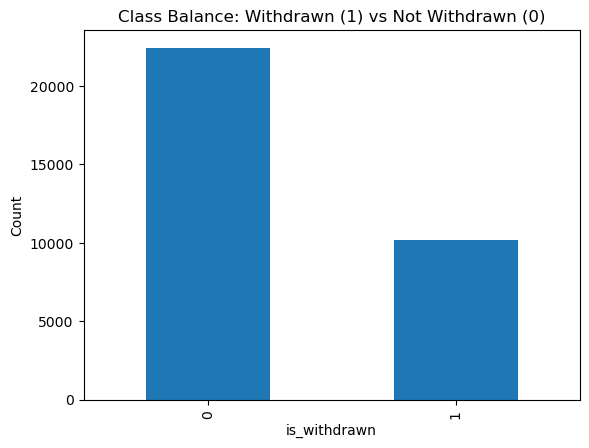

In [3]:
# -----------------------------
# Step 3) Define target: Focus on "withdrawn" vs "not withdrawn"
# -----------------------------
# Collapse into a binary target for dropout-focused modeling
df["is_withdrawn"] = (df["final_result"].astype(str).str.lower() == "withdrawn").astype(int)

print("\nTarget distribution (is_withdrawn):")
print(df["is_withdrawn"].value_counts())
print("\nTarget rate (withdrawn):", df["is_withdrawn"].mean())

# Plot class balance
plt.figure()
df["is_withdrawn"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Balance: Withdrawn (1) vs Not Withdrawn (0)")
plt.xlabel("is_withdrawn")
plt.ylabel("Count")
plt.show()

-----------------------------------------------------------------------------------------------------------------
### Methods of Analysis
#### Exploratory Data Analysis

Exploratory data analysis was conducted to review class balance, identify patterns across key variables, and determine whether adjustments to the research question or preprocessing steps were needed. Early review showed that non-withdrawal outcomes occurred more frequently than withdrawals, which indicates class imbalance and supports emphasizing recall, F1-score, and ROC-AUC during model evaluation rather than relying on accuracy alone (James et al., 2021).  

In [4]:
# -----------------------------
# Step 4) Useful univariate summaries
# -----------------------------
# Separate numeric and categorical
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print("\nNumeric columns:\n", num_cols)
print("\nCategorical columns (sample):\n", cat_cols[:25], "..." if len(cat_cols) > 25 else "")

print("\nNumeric describe:\n", df[num_cols].describe().T)


Numeric columns:
 ['id_student', 'num_of_prev_attempts', 'studied_credits', 'is_withdrawn']

Categorical columns (sample):
 ['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'final_result'] 

Numeric describe:
                         count           mean            std     min       25%       50%       75%        max
id_student            32593.0  706687.669131  549167.313855  3733.0  508573.0  590310.0  644453.0  2716795.0
num_of_prev_attempts  32593.0       0.163225       0.479758     0.0       0.0       0.0       0.0        6.0
studied_credits       32593.0      79.758691      41.071900    30.0      60.0      60.0     120.0      655.0
is_withdrawn          32593.0       0.311601       0.463155     0.0       0.0       0.0       1.0        1.0


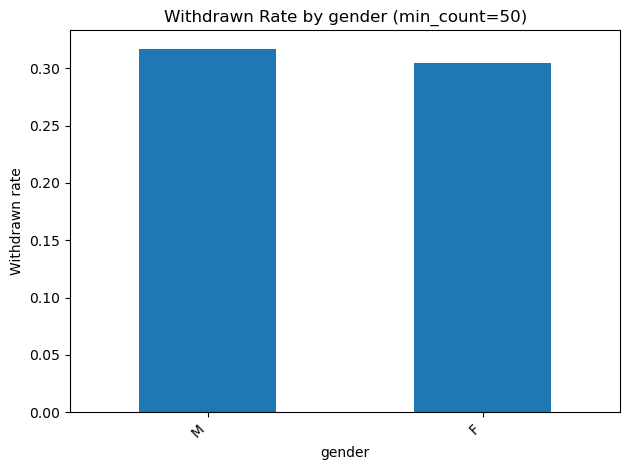

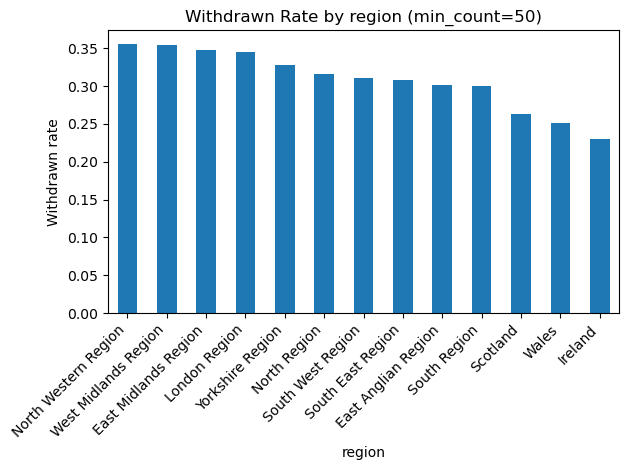

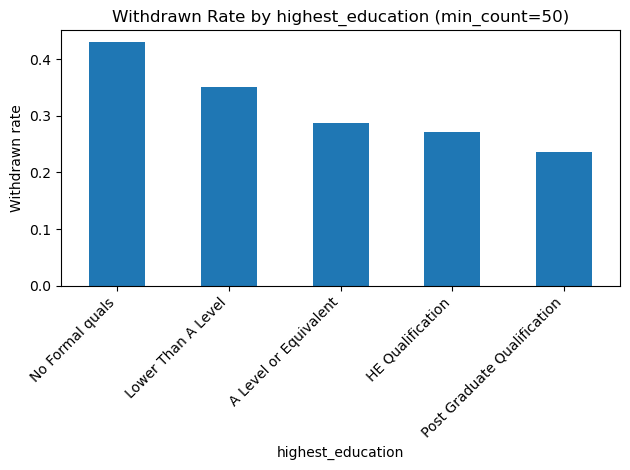

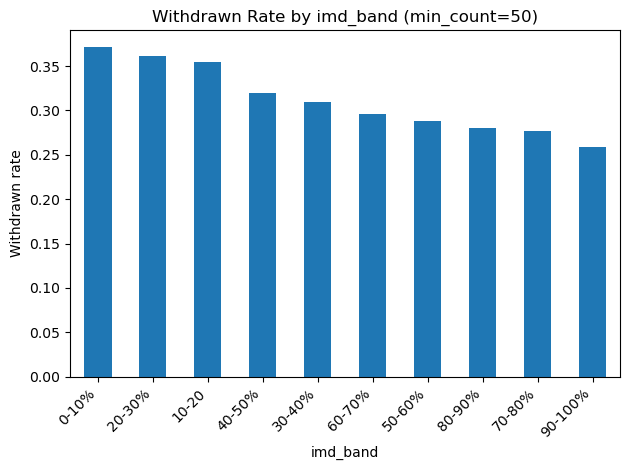

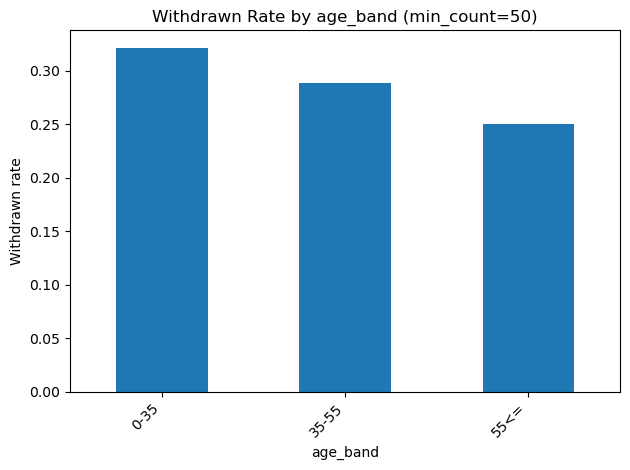

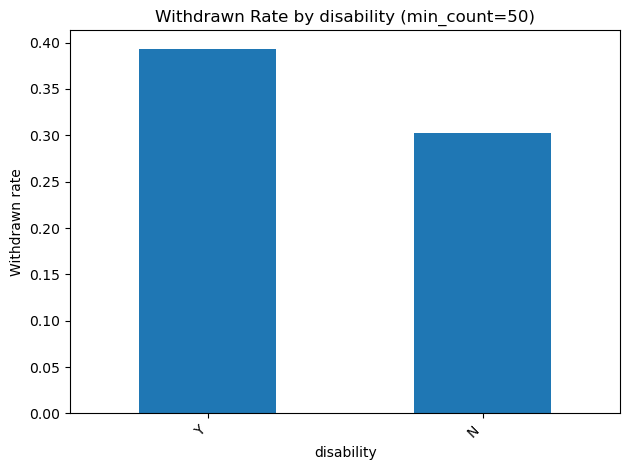

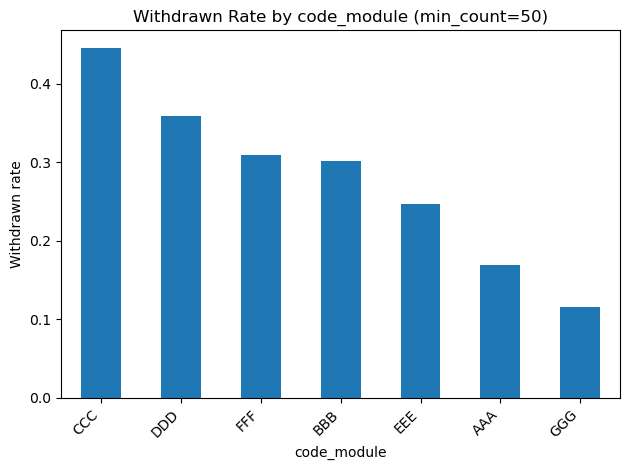

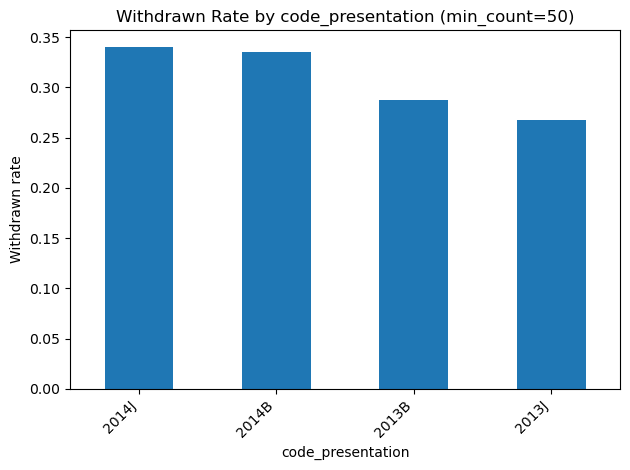

In [5]:
# -----------------------------
# Key visualizations
# Step 5A) Dropout rate by categorical features
# -----------------------------
def dropout_rate_by_category(data: pd.DataFrame, col: str, target: str = "is_withdrawn", min_count: int = 50):
    """Plots withdrawal rate by category and filters small categories for stability."""
    tmp = data[[col, target]].copy()
    tmp[col] = tmp[col].astype("category")

    counts = tmp[col].value_counts()
    keep = counts[counts >= min_count].index
    tmp = tmp[tmp[col].isin(keep)]

    rates = (
        tmp
        .groupby(col, observed=True)[target]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure()
    rates.plot(kind="bar")
    plt.title(f"Withdrawn Rate by {col} (min_count={min_count})")
    plt.xlabel(col)
    plt.ylabel("Withdrawn rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# Informative features
candidate_cat = [
    "gender", "region", "highest_education", "imd_band",
    "age_band", "disability", "code_module", "code_presentation"
]

for c in candidate_cat:
    if c in df.columns:
        dropout_rate_by_category(df, c, min_count=50)

<Figure size 640x480 with 0 Axes>

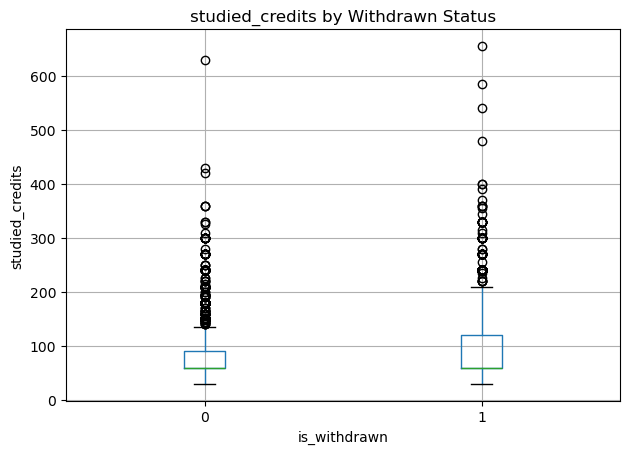

In [6]:
# -----------------------------
# Step 5B) Numeric comparison by withdrawal status
# -----------------------------
def boxplot_numeric_by_target(data: pd.DataFrame, num_col: str, target: str = "is_withdrawn"):
    plt.figure()
    data.boxplot(column=num_col, by=target)
    plt.title(f"{num_col} by Withdrawn Status")
    plt.suptitle("")  # removes default matplotlib title
    plt.xlabel("is_withdrawn")
    plt.ylabel(num_col)
    plt.tight_layout()
    plt.show()

# credits studied is a common numeric feature 
for n in ["studied_credits"]:
    if n in df.columns:
        boxplot_numeric_by_target(df, n)

In [7]:
# -----------------------------
# Step 6) Quick bivariate checks (study credits x age band)
# -----------------------------
if "studied_credits" in df.columns and "age_band" in df.columns:
    pivot = df.pivot_table(
        index="age_band",
        values="studied_credits",
        aggfunc=["mean", "median", "count"]
    )
    print("\nStudied credits by age_band:\n", pivot)


Studied credits by age_band:
                     mean          median           count
         studied_credits studied_credits studied_credits
age_band                                                
0-35           81.659257            60.0           22944
35-55          75.233754            60.0            9433
55<=           75.486111            60.0             216


In [8]:
# -----------------------------
# Step 7) Is adjustment of the data or questions necessary?
# Identify rare categories (potentially consolidate)
# -----------------------------
def rare_category_report(data: pd.DataFrame, col: str, top_n: int = 10):
    vc = data[col].value_counts(dropna=False)
    print(f"\n{col} - Top categories:\n", vc.head(top_n))
    print(f"{col} - Number of unique categories:", vc.shape[0])
    print(f"{col} - Categories with < 25 rows:", (vc < 25).sum())

for c in candidate_cat:
    if c in df.columns:
        rare_category_report(df, c)


gender - Top categories:
 gender
M    17875
F    14718
Name: count, dtype: int64
gender - Number of unique categories: 2
gender - Categories with < 25 rows: 0

region - Top categories:
 region
Scotland                3446
East Anglian Region     3340
London Region           3216
South Region            3092
North Western Region    2906
West Midlands Region    2582
South West Region       2436
East Midlands Region    2365
South East Region       2111
Wales                   2086
Name: count, dtype: int64
region - Number of unique categories: 13
region - Categories with < 25 rows: 0

highest_education - Top categories:
 highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64
highest_education - Number of unique categories: 5
highest_education - Categories with < 25 rows: 0

imd_band - Top categories:
 imd_band
20-30%

Modeling readiness notes:   
- If class imbalance is strong, plan for class weights or SMOTE  
- Consolidate rare categories to stabilize one-hot encoding  
- Use recall, ROC-AUC, and F1 in evaluation; recall is especially important for at-risk identification  


-----------------------------------------------------------------------------------------------------------------
### Data Preparation for Modeling

Several preprocessing steps were completed to prepare the dataset for predictive modeling:

1. The final result variable was converted into a binary outcome representing withdrawal versus non-withdrawal.  
2. Identifier variables that do not provide predictive value were removed.  
3. Categorical variables were transformed into numerical format using one-hot encoding.  
4. Numeric variables were reviewed for anomalies and distribution issues.  
5. The dataset was divided into training and testing subsets using a stratified split to preserve class proportions.  

Because withdrawal cases are less frequent than non-withdrawal cases, class weighting was incorporated so the minority class would receive more emphasis during training.


In [9]:
# -----------------------------
# Step 8) Final Modeling Dataset Prep
# -----------------------------

from sklearn.model_selection import train_test_split

# Drop identifiers that should not be predictive
drop_cols = ["id_student"] if "id_student" in df.columns else []
model_df = df.drop(columns=drop_cols)

# Separate features and target
X = model_df.drop(columns=["is_withdrawn", "final_result"], errors="ignore")
y = model_df["is_withdrawn"]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

'''
# After pd.get_dummies(...)
# X = pd.get_dummies(X, drop_first=True)
'''

# Clean column names for XGBoost (remove characters XGBoost disallows)
X.columns = (X.columns
             .astype(str)
             .str.replace(r"\[|\]", "", regex=True)   # remove [ and ]
             .str.replace(r"<", "lt", regex=False)    # replace < with 'lt'
            )


print("Final feature shape:", X.shape)

# Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)


Final feature shape: (32593, 40)
Training size: (22815, 40)
Test size: (9778, 40)


-----------------------------------------------------------------------------------------------------------------
### Model Development

Three classification models were developed to predict student withdrawal risk. Logistic Regression was selected as the baseline model because it provides interpretable coefficients and is widely used in applied predictive analytics. Random Forest and XGBoost were added to evaluate whether more complex ensemble approaches could improve predictive performance.


In [10]:
# -----------------------------
# Step 9) Build Logistic Regression Model
# -----------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Use class_weight to handle imbalance
model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6291675189200245
Precision: 0.43460582787440705
Recall: 0.6314407614046603
F1 Score: 0.5148514851485149
ROC-AUC: 0.6809999942952869

Confusion Matrix:
 [[4228 2503]
 [1123 1924]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.63      0.70      6731
           1       0.43      0.63      0.51      3047

    accuracy                           0.63      9778
   macro avg       0.61      0.63      0.61      9778
weighted avg       0.68      0.63      0.64      9778



The logistic regression model provides a baseline approach for identifying students at risk of withdrawal.

Key observations:  
- Recall is especially important because the goal is to correctly identify at-risk students  
- If recall is high but precision is lower, the model may flag more students than necessary, but this is often acceptable in early intervention scenarios  
- ROC-AUC provides an overall measure of model discrimination capability  

If recall is meaningfully above random guessing, the model demonstrates predictive value and suggests that the available features contain useful signals related to withdrawal behavior.

In [11]:
# -----------------------------
# Step 10) Feature importance via coefficients
# -----------------------------
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print(coefficients.head(10))
print(coefficients.tail(10))


                                 Feature  Coefficient
3                        code_module_CCC     1.304850
4                        code_module_DDD     0.825533
26     highest_education_No Formal quals     0.661379
6                        code_module_FFF     0.597348
2                        code_module_BBB     0.549479
5                        code_module_EEE     0.512792
25  highest_education_Lower Than A Level     0.379303
39                          disability_Y     0.297598
10               code_presentation_2014J     0.264248
9                code_presentation_2014B     0.236217
                                          Feature  Coefficient
27  highest_education_Post Graduate Qualification    -0.129641
32                                imd_band_50-60%    -0.157161
34                                imd_band_70-80%    -0.161016
35                                imd_band_80-90%    -0.168708
38                                 age_band_55lt=    -0.214544
17                          

In [12]:
# -----------------------------
# Step 11) Train Random Forest model
# -----------------------------
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

# Evaluate
print("Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))


Random Forest Performance:
Accuracy: 0.6487011658825935
Precision: 0.4114963503649635
Recall: 0.296028880866426
F1 Score: 0.3443405230005726
ROC AUC: 0.608053241259587


In [13]:
# -----------------------------
# Step 12) Train XGBoost model
# -----------------------------
# !pip install xgboost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train)
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

# Evaluate
print("XGBoost Performance:")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb_prob))

XGBoost Performance:
Accuracy: 0.6326447126201677
Precision: 0.4365836630207121
Recall: 0.615687561535937
F1 Score: 0.5108932461873639
ROC AUC: 0.6780412959801714


-----------------------------------------------------------------------------------------------------------------
### Model Evaluation and Comparison

Model performance is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. Because the goal of the project is early identification of students who may benefit from intervention, recall is treated as the most important metric. A model that misses too many at-risk students would have limited practical value even if its overall accuracy appears acceptable.


In [14]:
# -----------------------------
# Step 13) Compare models
# -----------------------------
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

print(results)

                 Model    Recall   ROC AUC
0  Logistic Regression  0.631441  0.681000
1        Random Forest  0.296029  0.608053
2              XGBoost  0.615688  0.678041


Identify best model for student dropout prediction  
Prioritize:  
- Primary metric: Recall  
- Secondary metric: ROC-AUC  

Because missing at-risk students is worse than flagging extra students

-----------------------------------------------------------------------------------------------------------------
### Interpreting Model Results

The next cells interpret model performance and feature importance to determine which variables are most associated with withdrawal risk and which model best supports the practical objective of identifying at-risk students.


In [15]:
# -----------------------------
# Step 14) Interpret feature importance: Random Forest
# -----------------------------
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importances.head(15))

                                 Feature  Importance
1                        studied_credits    0.121095
37                        age_band_35-55    0.050575
11                              gender_M    0.050028
0                   num_of_prev_attempts    0.042732
10               code_presentation_2014J    0.029913
9                code_presentation_2014B    0.028313
25  highest_education_Lower Than A Level    0.028072
8                code_presentation_2013J    0.027727
30                       imd_band_30-40%    0.027299
31                       imd_band_40-50%    0.026572
24    highest_education_HE Qualification    0.026330
28                        imd_band_10-20    0.026023
19                   region_South Region    0.025071
32                       imd_band_50-60%    0.024628
14                  region_London Region    0.024521


Model Comparison (sorted by Recall, then ROC_AUC):


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.629,0.435,0.631,0.515,0.681
1,XGBoost,0.633,0.437,0.616,0.511,0.678
2,Random Forest,0.649,0.411,0.296,0.344,0.608


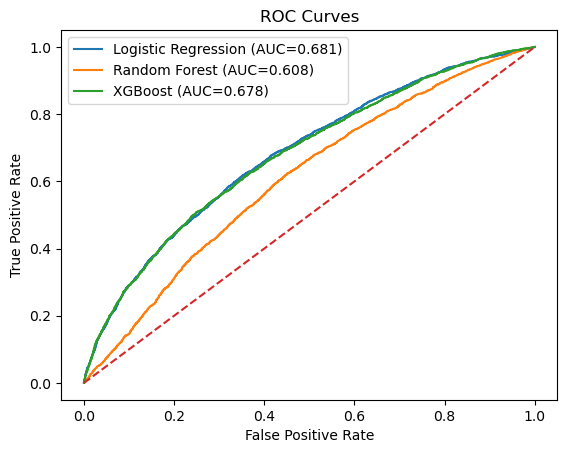

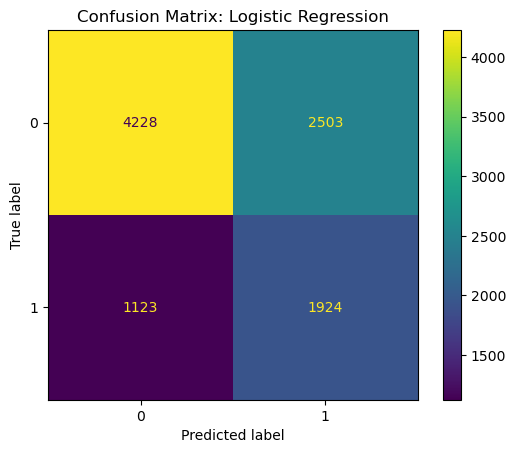

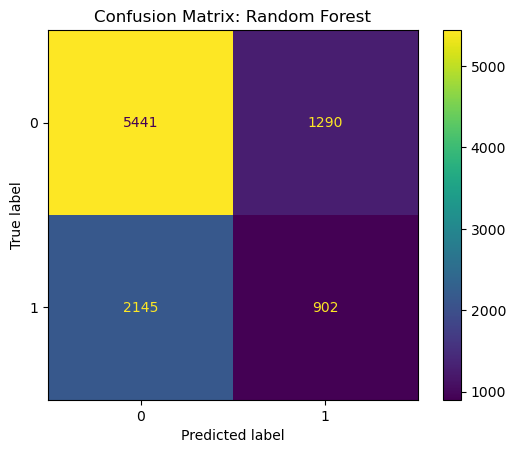

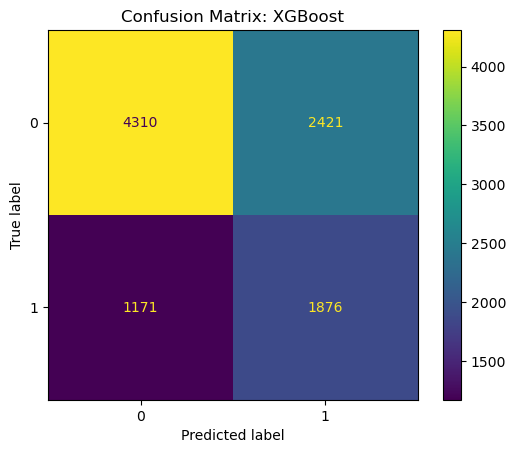


Selected best model (Recall-first): Logistic Regression


In [16]:
# -----------------------------
# Step 15) Interpret feature importance: Model Comparison + Plots 
# -----------------------------
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

def safe_predict_proba(m, X):
    """Return probability for positive class if available, else None."""
    if hasattr(m, "predict_proba"):
        return m.predict_proba(X)[:, 1]
    return None

def eval_model(name, m, X_test, y_test):
    y_pred = m.predict(X_test)
    y_prob = safe_predict_proba(m, X_test)

    out = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
        "_y_pred": y_pred,
        "_y_prob": y_prob
    }
    return out

# Ensure y is numeric 0/1
y_test_num = pd.Series(y_test).astype(int)

results = []

# Logistic Regression (your variable name: model)
results.append(eval_model("Logistic Regression", model, X_test, y_test_num))

# Random Forest (your variable name: rf_model)
results.append(eval_model("Random Forest", rf_model, X_test, y_test_num))

# XGBoost (optional; only if trained successfully)
if "xgb_model" in globals():
    results.append(eval_model("XGBoost", xgb_model, X_test, y_test_num))
else:
    print("Note: xgb_model not found; skipping XGBoost in comparison.")

# Results table
summary = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in results])
summary = summary.sort_values(by=["Recall", "ROC_AUC"], ascending=False).reset_index(drop=True)

pd.set_option("display.float_format", lambda x: f"{x:0.3f}")
print("Model Comparison (sorted by Recall, then ROC_AUC):")
display(summary)

# ROC curves
plt.figure()
for r in results:
    if r["_y_prob"] is None:
        continue
    fpr, tpr, _ = roc_curve(y_test_num, r["_y_prob"])
    plt.plot(fpr, tpr, label=f'{r["Model"]} (AUC={r["ROC_AUC"]:.3f})')
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

# Confusion matrices
for r in results:
    cm = confusion_matrix(y_test_num, r["_y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix: {r['Model']}")
    plt.show()

# Select best model for retention objective (Recall-first)
best_model_name = summary.loc[0, "Model"]
print(f"\nSelected best model (Recall-first): {best_model_name}")

-----------------------------------------------------------------------------------------------------------------
### Ethical Considerations and Responsible Use

Predictive analytics in education raises important ethical issues related to fairness, transparency, privacy, and responsible implementation. Variables such as socioeconomic status, disability status, and prior education may improve predictive performance, but they may also reflect broader structural inequalities. For that reason, model outputs should be used to support proactive advising, tutoring, and student outreach rather than punitive or exclusionary decisions.

Predictive outputs should inform human judgment rather than replace it. Responsible use requires transparency, regular performance monitoring, and periodic fairness checks across student groups.


In [17]:
# -----------------------------
# Step 16) Fairness / Subgroup Performance Check
# -----------------------------

from sklearn.metrics import confusion_matrix

# Align subgroup values with X_test rows (assumes X was derived from model_df without resetting index)
subgroup_candidates = ["gender", "age_band", "imd_band", "region", "disability", "highest_education"]

available = [c for c in subgroup_candidates if c in model_df.columns]
if not available:
    print("None of the expected subgroup columns were found in model_df.")
    print(f"Looked for: {subgroup_candidates}")
else:
    # Pick the selected best model object
    if best_model_name == "Logistic Regression":
        best_m = model
    elif best_model_name == "Random Forest":
        best_m = rf_model
    elif best_model_name == "XGBoost" and "xgb_model" in globals():
        best_m = xgb_model
    else:
        best_m = model  # fallback

    # Ground truth and predictions
    y_true = pd.Series(y_test).astype(int).reset_index(drop=True)
    y_pred = pd.Series(best_m.predict(X_test)).astype(int).reset_index(drop=True)

    # Pull subgroup columns aligned to X_test indices
    sub_df = model_df.loc[X_test.index, available].copy().reset_index(drop=True)

    def subgroup_metrics(y_t, y_p):
        tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
        precision = tp / (tp + fp) if (tp + fp) else np.nan
        recall = tp / (tp + fn) if (tp + fn) else np.nan
        fpr = fp / (fp + tn) if (fp + tn) else np.nan
        return precision, recall, fpr, tp, fp, fn, tn

    rows = []
    for col in available:
        for grp, idxs in sub_df.groupby(col).groups.items():
            y_t_g = y_true.loc[idxs]
            y_p_g = y_pred.loc[idxs]
            precision, recall, fpr, tp, fp, fn, tn = subgroup_metrics(y_t_g, y_p_g)
            rows.append({
                "Subgroup_Var": col,
                "Group": grp,
                "N": len(idxs),
                "Precision": precision,
                "Recall": recall,
                "FPR": fpr,
                "TP": tp, "FP": fp, "FN": fn, "TN": tn
            })

    fairness_table = pd.DataFrame(rows).sort_values(["Subgroup_Var", "Recall"], ascending=[True, True])
    pd.set_option("display.float_format", lambda x: f"{x:0.3f}")
    display(fairness_table)

,Subgroup_Var,Group,N,Precision,Recall,FPR,TP,FP,FN,TN
4,age_band,55<=,67,0.500,0.368,0.146,7,7,12,41
3,age_band,35-55,2833,0.426,0.584,0.312,470,633,335,1395
2,age_band,0-35,6878,0.437,0.651,0.400,1447,1863,776,2792
28,disability,N,8832,0.423,0.595,0.350,1585,2160,1077,4010
29,disability,Y,946,0.497,0.881,0.611,339,343,46,218
1,gender,M,5318,0.427,0.628,0.391,1059,1419,628,2212
0,gender,F,4460,0.444,0.636,0.350,865,1084,495,2016
34,highest_education,Post Graduate Qualification,93,0.111,0.167,0.320,3,24,15,51
31,highest_education,HE Qualification,1402,0.389,0.445,0.262,170,267,212,753
30,highest_education,A Level or Equivalent,4153,0.414,0.527,0.297,622,882,558,2091


Interpretations:  
- Lower Recall in a subgroup = more at-risk students missed in that group
- Higher FPR in a subgroup = more false alarms (extra outreach) for that group
- Treat very small N groups cautiously; consider aggregating or collecting more data

In [18]:
# -----------------------------
# Step 17) Model Performance Summary
# -----------------------------
best_row = summary.loc[0].to_dict()

print("Model Performance Summary")
print("----------------------------------------")
print(f"Best Model: {best_model_name}")
print(f"Accuracy: {best_row['Accuracy']:.3f}")
print(f"Precision: {best_row['Precision']:.3f}")
print(f"Recall: {best_row['Recall']:.3f}")
print(f"F1 Score: {best_row['F1']:.3f}")
print(f"ROC-AUC: {best_row['ROC_AUC']:.3f}")

Model Performance Summary
----------------------------------------
Best Model: Logistic Regression
Accuracy: 0.629
Precision: 0.435
Recall: 0.631
F1 Score: 0.515
ROC-AUC: 0.681


-----------------------------------------------------------------------------------------------------------------
### Analytic Summary

This project evaluated multiple supervised learning approaches to predict student withdrawal risk using the Open University Learning Analytics Dataset (OULAD).  

Across the tested models, the Logistic Regression model was selected as the preferred approach because it best aligned with the project objective of identifying at-risk early where recall is the most important performance measure.  

Model Performance Summary:  
- Model: Logistic Regression  
- Accuracy: 0.629  
- Precision: 0.435  
- Recall: 0.631  
- F1 Score: 0.515  
- ROC-AUC: 0.681  

Practical Recommendations:  
1. Use predicted risk scores to support proactive outreach (advising check-ins, tutoring referrals, workload planning support)  
2. Treat outputs as decision support, not an automated decision rule. Advisors should combine model results with qualitative context  
3. Choose an operating threshold intentionally (not necessarily 0.50). For retention interventions, it is often reasonable to prefer higher recall, as long as outreach is supportive and non-punitive

Deployment Readiness:  
This model is appropriate as a proof-of-concept, but a production deployment would require:  
- Threshold tuning based on institutional capacity for outreach  
- Monitoring for performance drift each term (recall/ROC-AUC) and periodic retraining  
- Clear documentation of model inputs, limitations, and intended use  

Ethical Considerations  
Predictive analytics in education can unintentionally reinforce inequities if risk scores correlate with demographic or socioeconomic factors. To mitigate this:  
- Evaluate model performance across demographic groups (e.g., gender, age band, IMD band) and monitor disparities over time  
- Avoid punitive use cases (e.g., restricting enrollment). Use the model only for supportive interventions and resource allocation  
- Maintain transparency with stakeholders about what the model does and does not measure, and protect student privacy throughout the data lifecycle

-----------------------------------------------------------------------------------------------------------------
### Final Model Selection  

This project evaluated Logistic Regression, Random Forest, and XGBoost models to predict student withdrawal risk using the Open University Learning Analytics Dataset. Because the primary goal of this project is early identification of at-risk students for proactive intervention, recall was the most important evaluation metric.

Among the evaluated models, Logistic Regression achieved the highest recall (0.631), compared to XGBoost (0.616) and Random Forest (0.296). This indicates that Logistic Regression was the most effective model at correctly identifying students who eventually withdrew. While Random Forest achieved the highest overall accuracy (0.649), its substantially lower recall suggests that it failed to identify many at-risk students, which limits its usefulness for intervention purposes.

Logistic Regression also achieved a strong ROC-AUC score of 0.681, indicating good overall discrimination between students who withdrew and those who persisted. Although XGBoost produced similar performance, Logistic Regression provided slightly higher recall and greater interpretability, which is especially important in educational settings where stakeholders must understand and trust model outputs.

These results demonstrate that student withdrawal risk is predictable using demographic and academic features, and that predictive models can support early identification of students who may benefit from additional academic support. Institutions could use these predictions to prioritize advising outreach, tutoring resources, and academic planning assistance.

However, predictive models must be used responsibly. Predictions should support human decision-making rather than replace it, and interventions should remain supportive rather than punitive. Institutions must also monitor model performance over time and evaluate fairness across demographic groups to ensure equitable outcomes.

Future work should include cross-validation, probability calibration, and additional feature engineering to further improve predictive performance. Overall, this analysis demonstrates that Logistic Regression provides a reliable and interpretable baseline model for identifying students at risk of withdrawal and supporting data-informed retention strategies.


-----------------------------------------------------------------------------------------------------------------
### Feature Importance Interpretation

To understand which factors most strongly influenced student withdrawal risk, feature importance was examined using Logistic Regression coefficients. These coefficients indicate both the strength and direction of the relationship between each predictor and withdrawal likelihood.

The analysis revealed that course-related variables were among the strongest predictors of withdrawal risk. In particular, enrollment in specific modules such as CCC (coefficient = 1.305), DDD (0.826), and FFF (0.597) showed the strongest positive association with withdrawal. This suggests that structural differences between courses—such as course difficulty, workload, or student support availability—may significantly influence persistence outcomes.

Educational background also emerged as a key predictor. Students with no formal qualifications (coefficient = 0.661) and those with education lower than A-level (0.379) were more likely to withdraw compared to students with higher prior academic preparation. This finding aligns with established retention research, which shows that academic readiness plays an important role in student persistence and success.

Disability status was also associated with increased withdrawal risk (coefficient = 0.298), highlighting the importance of ensuring accessible learning environments and providing appropriate academic accommodations and support services.

In contrast, several regional and socioeconomic indicators were associated with lower withdrawal risk. For example, students from Ireland (coefficient = -0.490), Wales (-0.323), and Scotland (-0.236) showed reduced withdrawal likelihood relative to the reference region. Additionally, students in the highest socioeconomic band (imd_band 90–100%, coefficient = -0.239) demonstrated lower withdrawal risk, which may reflect differences in financial stability, academic preparation, or access to support resources.

Presentation timing also showed some predictive value, with certain academic terms associated with slightly higher withdrawal probability. This may reflect differences in student enrollment patterns, external commitments, or academic workload during different academic periods.

Overall, these findings demonstrate that withdrawal risk is influenced by a combination of academic preparation, course characteristics, disability status, and socioeconomic context. Importantly, no single factor determines withdrawal (Tinto, 2012). Instead, the model identifies patterns across multiple variables that can help institutions proactively identify students who may benefit from additional academic support.

These insights can help institutions prioritize early advising interventions, tutoring services, and accessibility support. However, these factors should not be interpreted as causal determinants or used to penalize students. Instead, predictive outputs should be used responsibly to guide supportive interventions and improve student retention outcomes.

### Conclusion

This notebook demonstrates that predictive analytics can be used to identify students at risk of withdrawal using demographic, academic, and enrollment variables from the OULAD. Among the evaluated models, Logistic Regression provides the strongest fit for the project objective when recall and interpretability are prioritized. The model shows meaningful predictive capability beyond random classification and supports the use of data-informed early intervention strategies.

The results suggest that student withdrawal risk is influenced by multiple interacting factors, including course enrollment patterns, prior academic preparation, disability status, and socioeconomic context. Future improvements could include additional feature engineering, probability calibration, cross-validation, and fairness monitoring, as well as the incorporation of behavioral engagement variables such as learning platform activity or assignment completion patterns.


### References

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research, 16*, 321–357. https://doi.org/10.1613/jair.953

Denley, T. (2019). How predictive analytics and choice architecture can improve student success. *EDUCAUSE Review, 54*(4), 10–25.

Han, J., Kamber, M., & Pei, J. (2012). *Data mining: Concepts and techniques* (3rd ed.). Morgan Kaufmann.

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An introduction to statistical learning: With applications in R* (2nd ed.). Springer.

Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2017). Open University Learning Analytics Dataset. *Scientific Data, 4*, Article 170171. https://doi.org/10.1038/sdata.2017.171

Tinto, V. (2012). *Completing college: Rethinking institutional action*. University of Chicago Press.
